In [5]:
import pandas as pd
import matplotlib.pyplot as plt

import os
import sys

import pandas as pd
import numpy as np

work_dir = "/home/handb/GeoSTHN"

os.chdir(work_dir)
sys.path.append(work_dir)

正在读取数据: tgb/DATA/thgl_github_subset/thgl-github-subset_edgelist.csv ...
总节点数: 36818
最大度数: 3573.0
平均度数: 2.72
中位数度数: 2.0

=== 阈值敏感性分析 ===
度数 <= 5 的节点占比 (Cold Nodes): 97.01%
度数 <= 10 的节点占比 (Cold Nodes): 99.18%
度数 <= 20 的节点占比 (Cold Nodes): 99.75%
度数 <= 50 的节点占比 (Cold Nodes): 99.94%
度数 <= 100 的节点占比 (Cold Nodes): 99.97%

分布图已保存为 distribution_check.png
请查看该图以确认长尾效应。


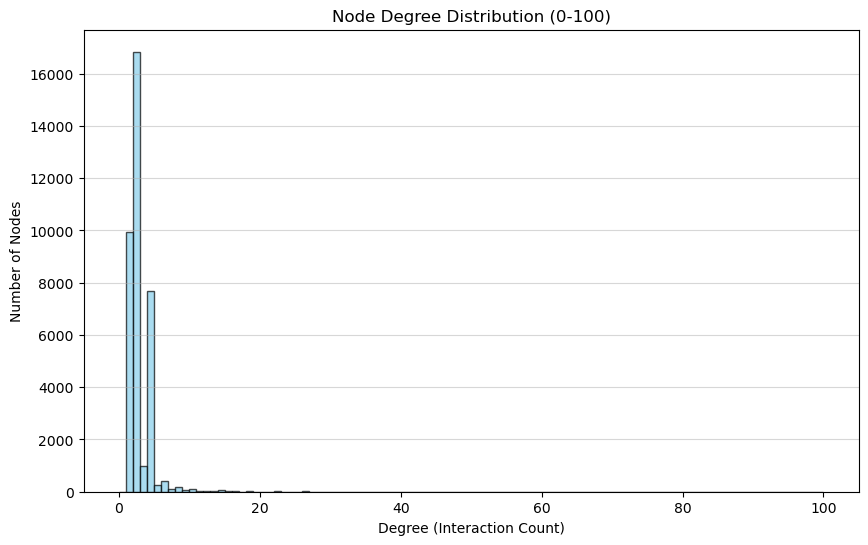

In [6]:
# 1. 设置数据路径 (根据你的 TGB 数据下载位置调整)
# 通常 TGB 会把 CSV 下载到 tgb/datasets/thgl_github/ 下
dataset = "thgl-github-subset"
DATA_PATH = f"tgb/DATA/{dataset.replace('-','_')}/{dataset}_edgelist.csv"


def analyze_degree_distribution():
    print(f"正在读取数据: {DATA_PATH} ...")

    # 检查文件是否存在
    if not os.path.exists(DATA_PATH):
        print(f"错误: 找不到文件 {DATA_PATH}。请确认你已经运行过 dataset 下载脚本。")
        return

    # 读取 CSV (TGB 格式通常包含: ts, src, dst, weight)
    df = pd.read_csv(DATA_PATH)

    # 2. 计算节点度数 (入度 + 出度)
    # 这是一个简化统计，统计每个节点在整个历史中出现的总次数
    src_counts = df["head"].value_counts()
    dst_counts = df["tail"].value_counts()

    # 合并 src 和 dst 的计数，fillna(0) 填充那些只做 src 或只做 dst 的节点
    total_degrees = src_counts.add(dst_counts, fill_value=0)

    print(f"总节点数: {len(total_degrees)}")
    print(f"最大度数: {total_degrees.max()}")
    print(f"平均度数: {total_degrees.mean():.2f}")
    print(f"中位数度数: {total_degrees.median()}")

    # 3. 关键：计算不同阈值下的节点占比
    thresholds = [5, 10, 20, 50, 100]
    print("\n=== 阈值敏感性分析 ===")
    for k in thresholds:
        # 计算度数小于等于 k 的节点比例
        ratio = (total_degrees <= k).mean() * 100
        print(f"度数 <= {k} 的节点占比 (Cold Nodes): {ratio:.2f}%")

    # 4. 可视化长尾分布 (只画度数 < 100 的部分，否则长尾看不清)
    plt.figure(figsize=(10, 6))
    plt.hist(
        total_degrees,
        bins=100,
        range=(0, 100),
        color="skyblue",
        edgecolor="black",
        alpha=0.7,
    )
    plt.title("Node Degree Distribution (0-100)")
    plt.xlabel("Degree (Interaction Count)")
    plt.ylabel("Number of Nodes")
    plt.grid(axis="y", alpha=0.5)

    # 保存图片，写论文时可以用作 Motivation 图
    plt.savefig("distribution_check.png")
    print("\n分布图已保存为 distribution_check.png")
    print("请查看该图以确认长尾效应。")


if __name__ == "__main__":
    analyze_degree_distribution()